In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use("seaborn-v0_8-colorblind")

In [2]:
def plot_performance_vs_dist(
    performance_dict,
    hdiv_dict,
    title="Segmentation performance vs Wasserstein distance",
    xlabel="Wasserstein distance",
    ylabel="Performance (F1-score)",
    colors=None,
    markers=None,
    figsize=(10, 7),
    fontsize=20,
    point_size=150,
    save_path="/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures",
    save_name="performance_vs_wass",
    x_ticks=None,
):
    """Scatter-plot segmentation performance against repeated h-divergence values."""
    shared_datasets = [dataset for dataset in performance_dict if dataset in hdiv_dict]
    if not shared_datasets:
        raise ValueError("No overlapping datasets found between performance and hdiv dictionaries.")

    if colors is None:
        colors = {
            "EPFL": "#4C78A8",
            "Hmito": "#F58518",
            "Rmito": "#54A24B",
            "VNC": "#C44E52",
        }
    if markers is None:
        markers = {
            "EPFL": "^",
            "Hmito": "o",
            "Rmito": "s",
            "VNC": "D",
        }

    fig, ax = plt.subplots(figsize=figsize)

    for dataset in shared_datasets:
        hdiv_values = list(hdiv_dict[dataset])
        if not isinstance(hdiv_values, (list, tuple)):
            raise ValueError(f"H-divergence values for {dataset} must be a list or tuple.")

        x_values = list(hdiv_values)
        y_values = list(performance_dict[dataset])
        _= ax.scatter(
            x_values,
            y_values,
            s=point_size,
            color=colors.get(dataset, None),
            marker=markers.get(dataset, "o"),
            edgecolor="black",
            linewidth=0.6,
            label=dataset,
        )

    _ =ax.set_xlabel(xlabel, fontsize=fontsize)
    _ =ax.set_ylabel(ylabel, fontsize=fontsize)
    _ =ax.set_title(title, fontsize=fontsize)
    _ =ax.grid(True, linestyle="--", alpha=0.35)
    _ =ax.legend(frameon=False, loc="best", fontsize=fontsize - 2)
    _ =ax.tick_params(axis="both", labelsize=fontsize - 2)

    if x_ticks is not None:
        ax.set_xticks(list(x_ticks))
        ax.set_xticklabels([f"{tick:.3f}" for tick in x_ticks])

    plt.tight_layout()
    plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches=None)
    plt.show()

In [3]:
from typing import Union

def get_result_path(
    source: str,
    target: str,
    id: int,
    save_postfix: Union[str, None] = None,
    abbrv: bool = False,
    distance: str = "MMD",
):
    folder_path = f"/g/kreshuk/talks/domain_gap/experiments/patch_classification/{source}_to_{target}/{distance}/predictions"
    if save_postfix:
        if abbrv:
            filename = f"{distance}_{source[0].upper()}to{target[0].upper()}_{save_postfix}_{id}.npz"
        else:
            filename = f"{distance}_{source}_to_{target}_{save_postfix}_{id}.npz"
    else:
        if abbrv:
            filename = f"{distance}_{source[0].upper()}to{target[0].upper()}_{id}.npz"
        else:
            filename = f"{distance}_{source}_to_{target}_{id}.npz"
    data_path = os.path.join(folder_path, filename)
    return data_path

In [4]:
def get_dist_all(
    source: str,
    targets: list,
    num_repeats: int = 5,
    save_name_postfix: Union[str, None] = None,
    start_id: int = 1,
    abbrv: bool = True,
    distance: str = "MMD",
    seperated: bool = False,
):
    f1_and_dists = {}
    for t in targets:
        (
            f1_and_dists[f"{source[0].upper()}to{t[0].upper()}_f1"],
            f1_and_dists[f"{source[0].upper()}to{t[0].upper()}_dist"],
        ) = get_domain_gap_dist(
            source,
            t,
            num_repeats,
            save_name_postfix,
            start_id,
            abbrv,
            distance,
            seperated,
        )
    return f1_and_dists

In [5]:
import sklearn.metrics as metrics

def prediction_evaluation(predictions, labels):
    accuracy_error = 1.0 - metrics.accuracy_score(labels, predictions)
    precision = metrics.precision_score(labels, predictions)
    recall = metrics.recall_score(labels, predictions)
    f1_score = metrics.f1_score(labels, predictions)
    return accuracy_error, precision, recall, f1_score

In [6]:
def get_domain_gap_dist(
    source: str,
    target: str,
    num_repeats: int,
    save_name_postfix: Union[str, None] = None,
    start_id: int = 1,
    abbrv: bool = False,
    distance: str = "MMD",
    seperated: bool = False,
):
    f1_scores = np.zeros(num_repeats)
    if seperated:
        dists = np.zeros((num_repeats, 2))
    else:
        dists = np.zeros(num_repeats)
    for i in range(num_repeats):
        id = start_id + i
        data_path = get_result_path(
            source,
            target,
            id,
            save_name_postfix,
            abbrv=abbrv,
            distance=distance,
        )
        with np.load(data_path, "r") as f:
            _, _, _, f1_scores[i] = prediction_evaluation(
                f["prediction"], f["gt_label"]
            )
            if seperated:
                dists[i, 0] = f["dist"][0]
                dists[i, 1] = f["dist"][1]
            else:
                dists[i] = f["dist"]
    return f1_scores, dists

In [7]:
Rmito_gaps = get_dist_all(source='Rmito', targets=["epfl", "Hmito", "Rmito", "VNC"], save_name_postfix="pv_norm", distance="OT")

In [8]:
Rmito_f1 = {
    "EPFL": Rmito_gaps["RtoE_f1"],
    "Hmito": Rmito_gaps["RtoH_f1"],
    "Rmito": Rmito_gaps["RtoR_f1"],
    "VNC": Rmito_gaps["RtoV_f1"],
}

Rmito_wass = {
    "EPFL": Rmito_gaps["RtoE_dist"],
    "Hmito": Rmito_gaps["RtoH_dist"],
    "Rmito": Rmito_gaps["RtoR_dist"],
    "VNC": Rmito_gaps["RtoV_dist"],
}

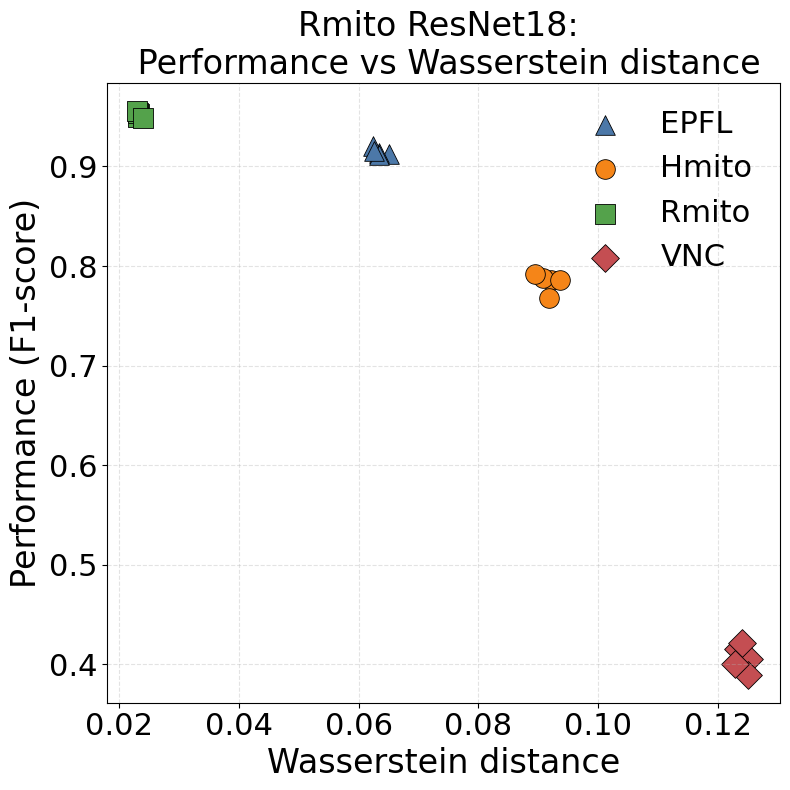

In [10]:
plot_performance_vs_dist(
    Rmito_f1,
    Rmito_wass,
    title="Rmito ResNet18: \n Performance vs Wasserstein distance",
    save_name="Rmito_RN18_perf_vs_wass_square",
    figsize=(8, 8),
    fontsize=24,
    point_size=200
)

In [11]:
epfl_gaps = get_dist_all(source='epfl', targets=["epfl", "Hmito", "Rmito", "VNC"], save_name_postfix="pv_norm", distance="OT")

In [12]:
EPFL_f1 = {
    "EPFL": epfl_gaps["EtoE_f1"],
    "Hmito": epfl_gaps["EtoH_f1"],
    "Rmito": epfl_gaps["EtoR_f1"],
    "VNC": epfl_gaps["EtoV_f1"],
}

EPFL_wass = {
    "EPFL": epfl_gaps["EtoE_dist"],
    "Hmito": epfl_gaps["EtoH_dist"],
    "Rmito": epfl_gaps["EtoR_dist"],
    "VNC": epfl_gaps["EtoV_dist"],
}

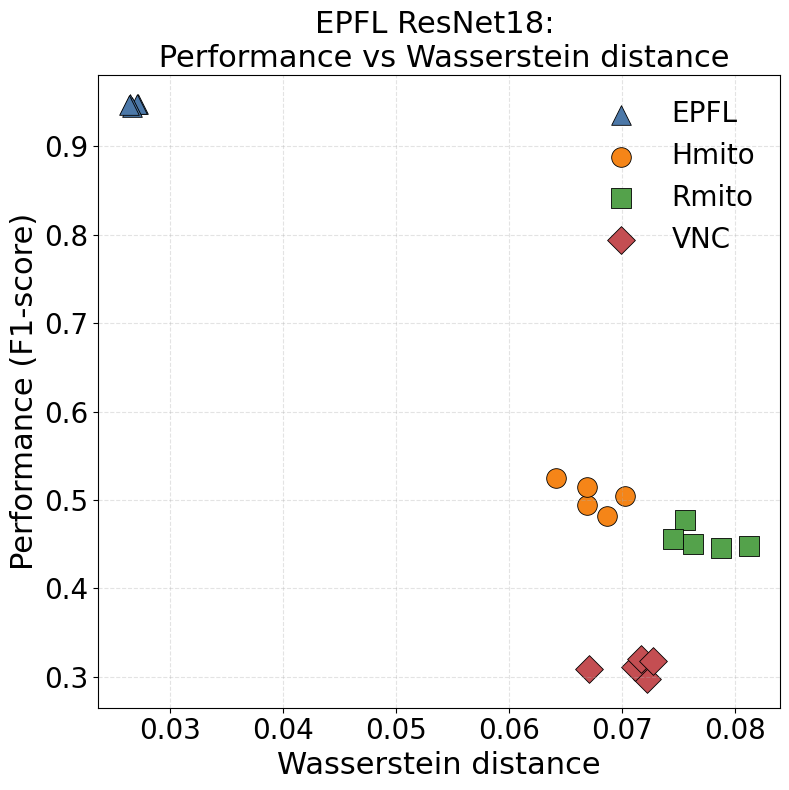

In [13]:
plot_performance_vs_dist(
    EPFL_f1,
    EPFL_wass,
    title="EPFL ResNet18: \n Performance vs Wasserstein distance",
    save_name="EPFL_RN18_perf_vs_wass_square",
    figsize=(8, 8),
    fontsize=22,
    point_size=200
)

In [14]:
epfl_sep_gaps = get_dist_all(source='epfl', targets=["epfl", "Hmito", "Rmito", "VNC"], save_name_postfix="pvn_sep", distance="OT", seperated=True)

In [15]:
EPFL_sep_f1 = {
    "EPFL": epfl_sep_gaps["EtoE_f1"],
    "Hmito": epfl_sep_gaps["EtoH_f1"],
    "Rmito": epfl_sep_gaps["EtoR_f1"],
    "VNC": epfl_sep_gaps["EtoV_f1"],
}

EPFL_sep0_wass = {
    "EPFL": epfl_sep_gaps["EtoE_dist"][:, 0],
    "Hmito": epfl_sep_gaps["EtoH_dist"][:, 0],
    "Rmito": epfl_sep_gaps["EtoR_dist"][:, 0],
    "VNC": epfl_sep_gaps["EtoV_dist"][:, 0],
}

EPFL_sep1_wass = {
    "EPFL": epfl_sep_gaps["EtoE_dist"][:, 1],
    "Hmito": epfl_sep_gaps["EtoH_dist"][:, 1],
    "Rmito": epfl_sep_gaps["EtoR_dist"][:, 1],
    "VNC": epfl_sep_gaps["EtoV_dist"][:, 1],
}

EPFL_sep_avg_wass = {
    "EPFL": np.mean(epfl_sep_gaps["EtoE_dist"], axis=1),
    "Hmito": np.mean(epfl_sep_gaps["EtoH_dist"], axis=1),
    "Rmito": np.mean(epfl_sep_gaps["EtoR_dist"], axis=1),
    "VNC": np.mean(epfl_sep_gaps["EtoV_dist"], axis=1),
}

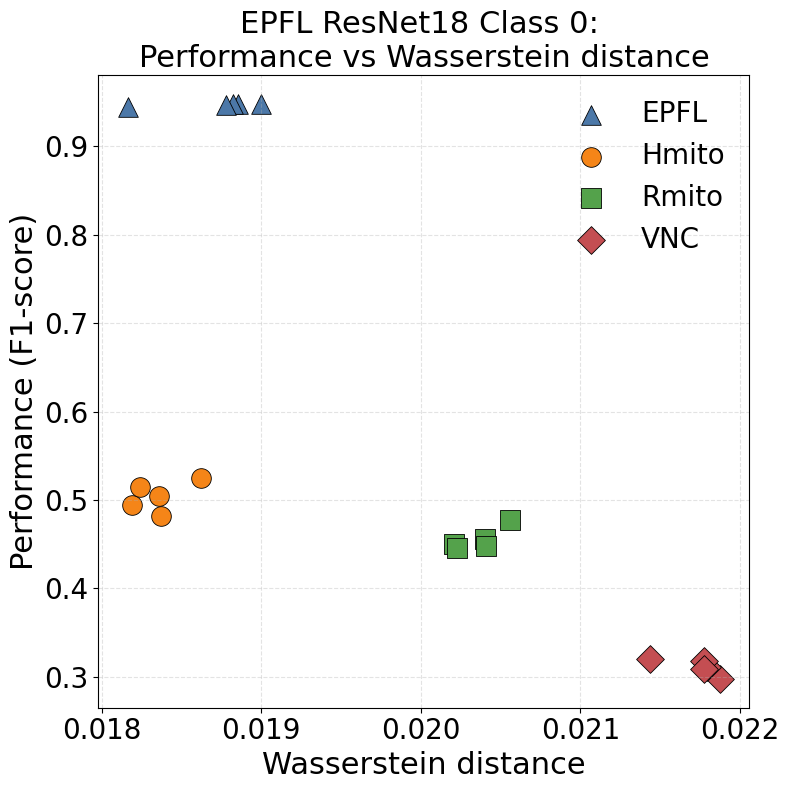

In [16]:
plot_performance_vs_dist(
    EPFL_sep_f1,
    EPFL_sep0_wass,
    title="EPFL ResNet18 Class 0: \nPerformance vs Wasserstein distance",
    save_name="EPFL_RN18_perf_vs_wass_class0_square",
    figsize=(8, 8),
    fontsize=22,
    point_size=200,
    x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

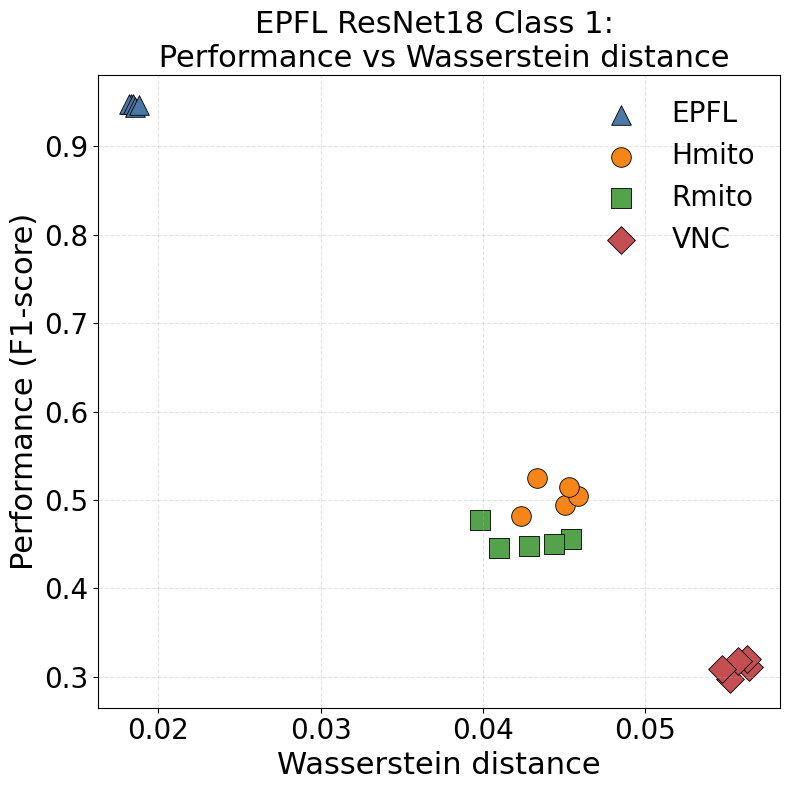

In [17]:
plot_performance_vs_dist(
    EPFL_sep_f1,
    EPFL_sep1_wass,
    title="EPFL ResNet18 Class 1: \n Performance vs Wasserstein distance",
    save_name="EPFL_RN18_perf_vs_wass_class1_square",
    figsize=(8, 8),
    fontsize=22,
    point_size=200
)

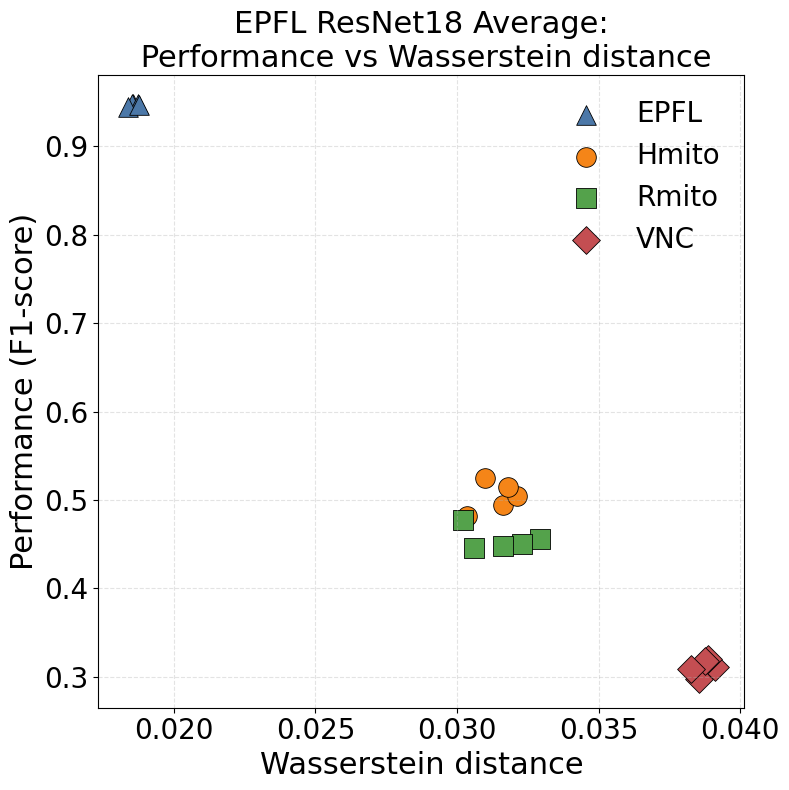

In [18]:
plot_performance_vs_dist(
    EPFL_sep_f1,
    EPFL_sep_avg_wass,
    title="EPFL ResNet18 Average:\n Performance vs Wasserstein distance",
    save_name="EPFL_RN18_perf_vs_wass_avg_square",
    figsize=(8, 8),
    fontsize=22,
    point_size=200
)

In [19]:
Rmito_sep_gaps = get_dist_all(source='Rmito', targets=["epfl", "Hmito", "Rmito", "VNC"], save_name_postfix="pvn_sep", distance="OT", seperated=True)

In [20]:
Rmito_sep_f1 = {
    "EPFL": Rmito_sep_gaps["RtoE_f1"],
    "Hmito": Rmito_sep_gaps["RtoH_f1"],
    "Rmito": Rmito_sep_gaps["RtoR_f1"],
    "VNC": Rmito_sep_gaps["RtoV_f1"],
}

Rmito_sep0_wass = {
    "EPFL": Rmito_sep_gaps["RtoE_dist"][:, 0],
    "Hmito": Rmito_sep_gaps["RtoH_dist"][:, 0],
    "Rmito": Rmito_sep_gaps["RtoR_dist"][:, 0],
    "VNC": Rmito_sep_gaps["RtoV_dist"][:, 0],
}

Rmito_sep1_wass = {
    "EPFL": Rmito_sep_gaps["RtoE_dist"][:, 1],
    "Hmito": Rmito_sep_gaps["RtoH_dist"][:, 1],
    "Rmito": Rmito_sep_gaps["RtoR_dist"][:, 1],
    "VNC": Rmito_sep_gaps["RtoV_dist"][:, 1],
} 

Rmito_sep_avg_wass = {
    "EPFL": np.mean(Rmito_sep_gaps["RtoE_dist"], axis=1),
    "Hmito": np.mean(Rmito_sep_gaps["RtoH_dist"], axis=1),
    "Rmito": np.mean(Rmito_sep_gaps["RtoR_dist"], axis=1),
    "VNC": np.mean(Rmito_sep_gaps["RtoV_dist"], axis=1),
}

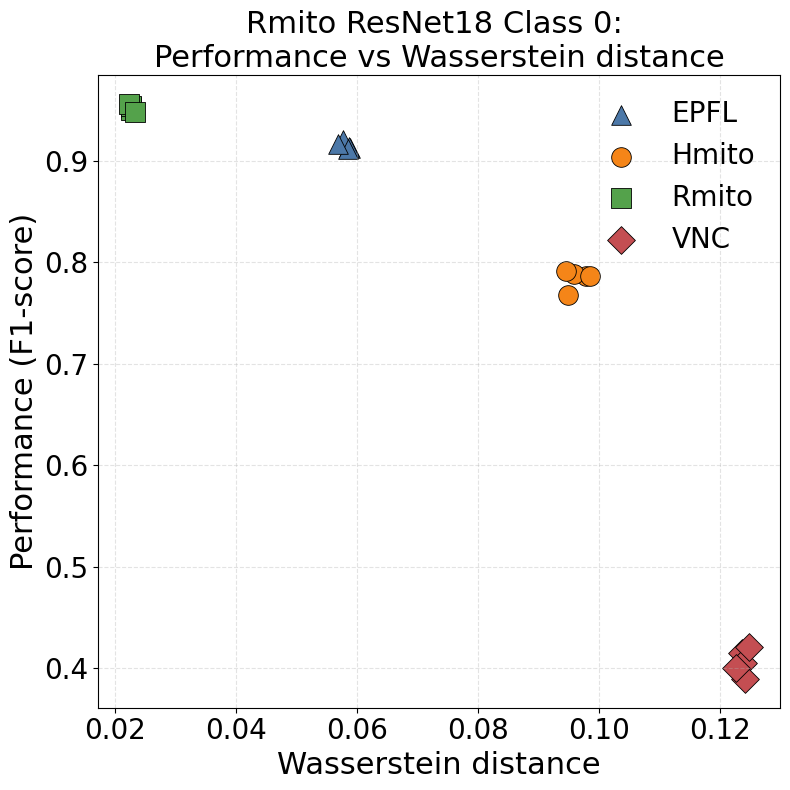

In [21]:
plot_performance_vs_dist(
    Rmito_sep_f1,
    Rmito_sep0_wass,
    title="Rmito ResNet18 Class 0: \nPerformance vs Wasserstein distance",
    save_name="Rmito_RN18_perf_vs_wass_class0_square",
    figsize=(8, 8),
    fontsize=22,
    point_size=200,
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

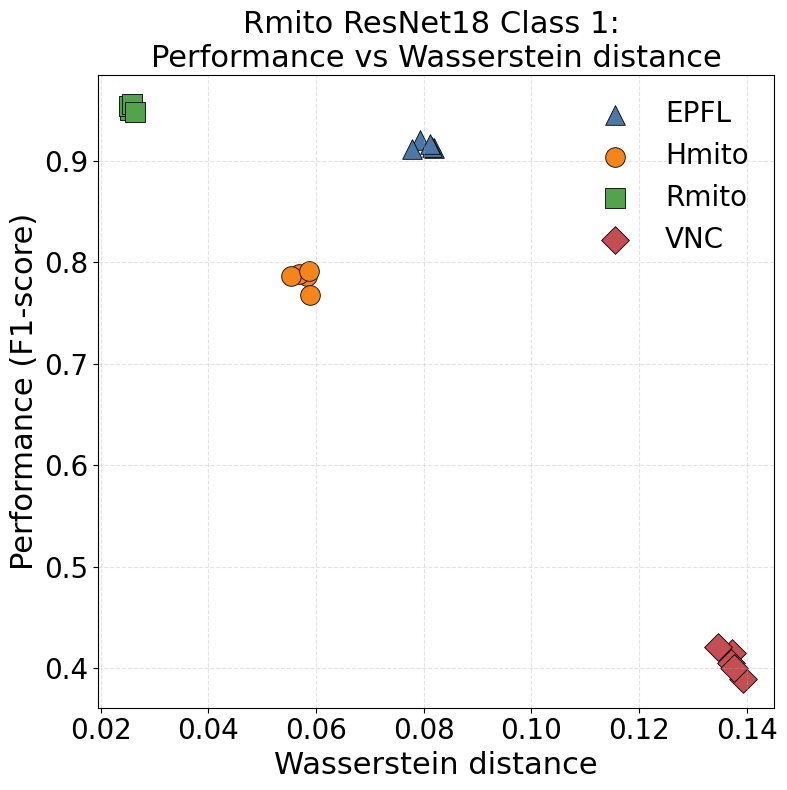

In [22]:
plot_performance_vs_dist(
    Rmito_sep_f1,
    Rmito_sep1_wass,
    title="Rmito ResNet18 Class 1: \nPerformance vs Wasserstein distance",
    save_name="Rmito_RN18_perf_vs_wass_class1_square",
    figsize=(8, 8),
    fontsize=22,
    point_size=200,
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)

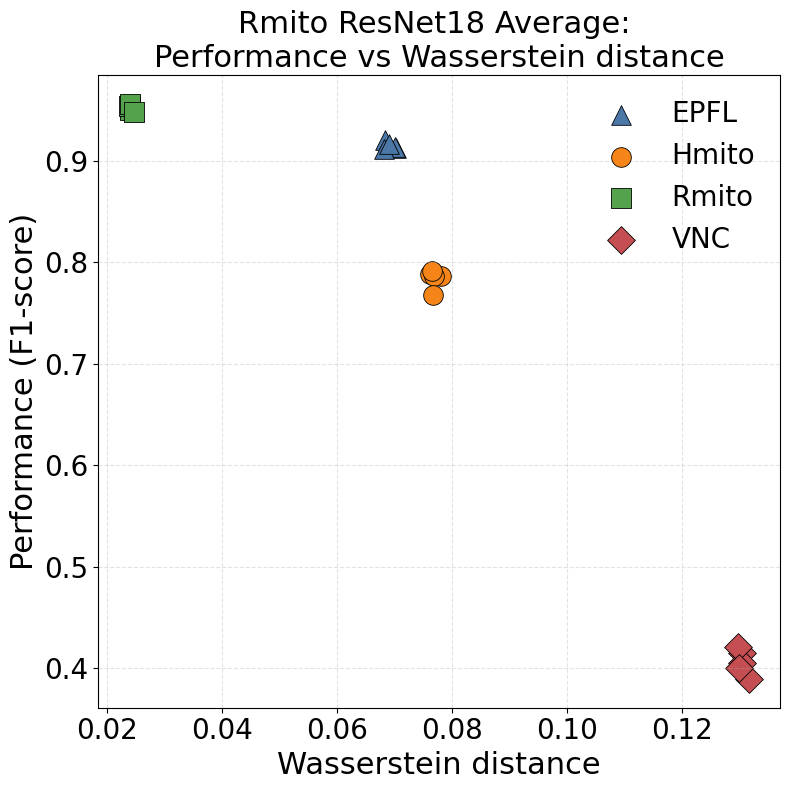

In [23]:
plot_performance_vs_dist(
    Rmito_sep_f1,
    Rmito_sep_avg_wass,
    title="Rmito ResNet18 Average: \nPerformance vs Wasserstein distance",
    save_name="Rmito_RN18_perf_vs_wass_avg_square",
    figsize=(8, 8),
    fontsize=22,
    point_size=200,
    # x_ticks=[0.018, 0.019, 0.020, 0.021, 0.022]
)